<div style="background: linear-gradient(135deg, #2D6A4F 0%, #2D6A4F 100%); padding: 24px; border-radius: 12px; color: white;">
    <h1 style="margin: 0 0 8px 0; color: #ffffff; font-size: 26px; font-weight: 800; border-bottom: none; padding: 0;">Hotel Booking Project</h1>
    <div style="background: rgba(255, 255, 255, 0.15); padding: 8px 14px; border-radius: 6px; font-size: 13px; display: inline-block;">
        <strong>Author:</strong> Kathryn Penrod &nbsp;•&nbsp; 
        <strong>Question:</strong> Should we increase our parking lot size?
    </div>
</div>

In [1]:
import numpy as np 
import pandas as pd 
import scipy as sp 
from scipy import stats 
import matplotlib 
import sqlite3 
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates
import seaborn as sns 
import sklearn 
from sklearn.preprocessing import StandardScaler 
from sklearn.decomposition import PCA 
import warnings 
import re

all_dfs = pd.read_pickle('all_clean_dfs2.pkl')
df = all_dfs['df']
clean_df = all_dfs['clean_df']

In [2]:
#parking spaces counts
parking_counts = clean_df['required_car_parking_spaces'].value_counts().sort_index()
print("Distribution of Parking Spaces Requested per Booking:")
print(parking_counts)

Distribution of Parking Spaces Requested per Booking:
required_car_parking_spaces
0    10758
1     1203
2        2
Name: count, dtype: int64


Max Parking Demand on a Single Day: 49 spaces


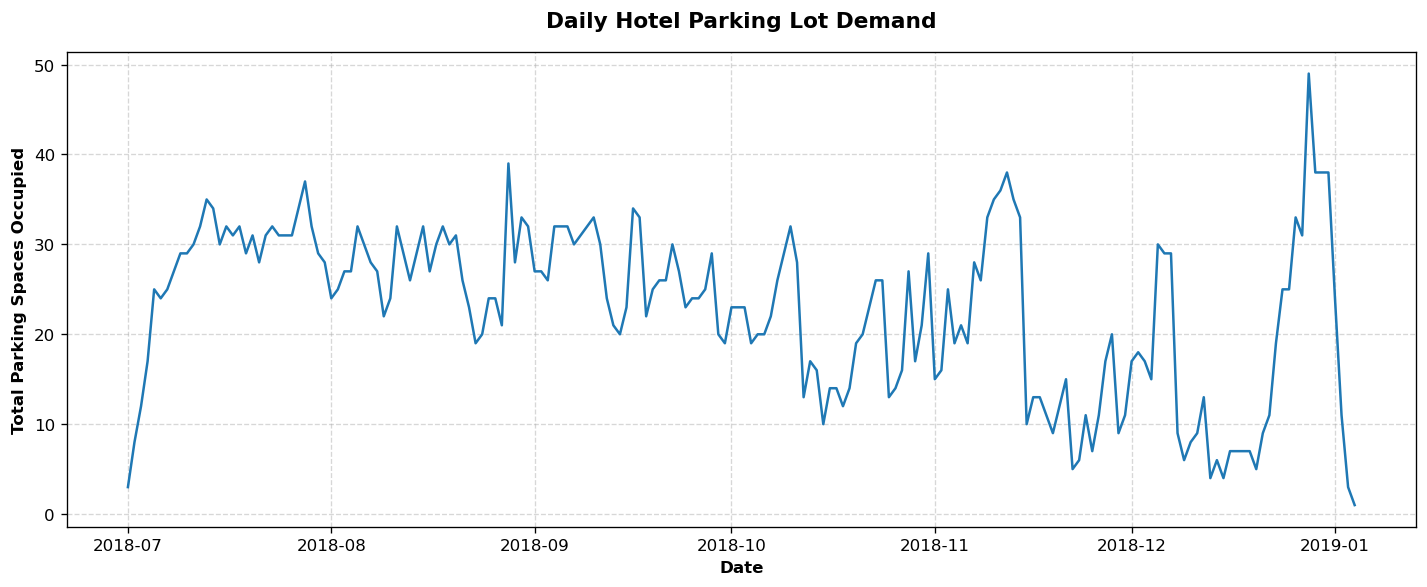

In [3]:
#parking spaces used over time

if 'total_stay_length' not in clean_df.columns:
    clean_df['total_stay_length'] = clean_df['stays_in_weekend_nights'] + clean_df['stays_in_week_nights']
clean_df['arrival_dt'] = pd.to_datetime(clean_df['arrival_date'], errors='coerce')

parking_df = clean_df[(clean_df['required_car_parking_spaces'] > 0) & (clean_df['arrival_dt'].notna())].copy()

daily_parking = []
for _, row in parking_df.iterrows():
    dates = pd.date_range(start=row['arrival_dt'], periods=max(1, row['total_stay_length']), freq='D')
    for d in dates:
        daily_parking.append({'date': d, 'spaces_needed': row['required_car_parking_spaces']})

parking_timeline = pd.DataFrame(daily_parking).groupby('date')['spaces_needed'].sum().reset_index()

max_demand = parking_timeline['spaces_needed'].max()
print(f"Max Parking Demand on a Single Day: {max_demand} spaces")

#formatting figure
plt.figure(figsize=(12, 5), dpi=120)
plt.plot(parking_timeline['date'], parking_timeline['spaces_needed'], color='#1f78b4', linewidth=1.5)
plt.title("Daily Hotel Parking Lot Demand", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Date", fontsize=10, fontweight="bold")
plt.ylabel("Total Parking Spaces Occupied", fontsize=10, fontweight="bold")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

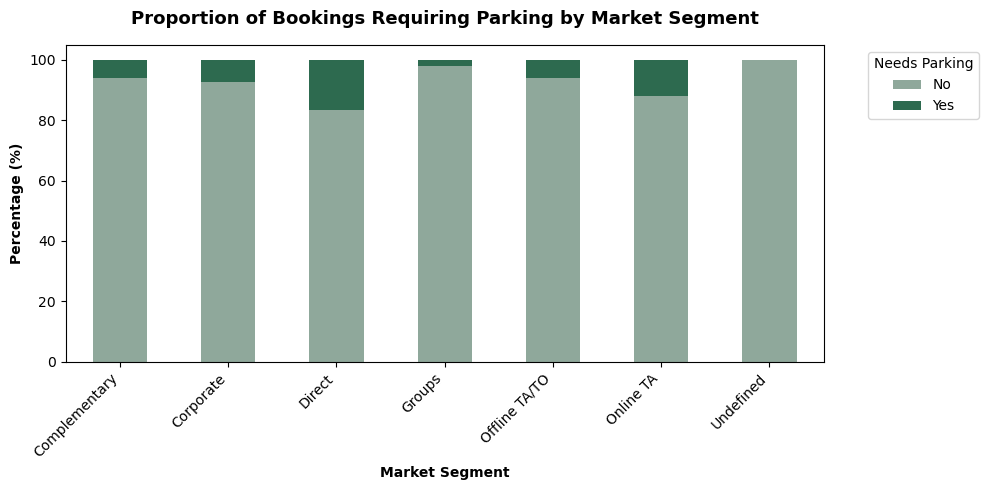

In [15]:
#market segment parking y/n bar chart


clean_df['needs_parking'] = clean_df['required_car_parking_spaces'] > 0

parking_by_segment = pd.crosstab(
    clean_df['market_segment'], 
    clean_df['needs_parking'], 
    normalize='index'
) * 100


plt.figure(figsize=(10, 5), dpi=120)
parking_by_segment.plot(kind='bar', stacked=True, color=['#8FA89B', '#2D6A4F'], figsize=(10, 5), edgecolor='none')
plt.title("Proportion of Bookings Requiring Parking by Market Segment", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Market Segment", fontsize=10, fontweight="bold")
plt.ylabel("Percentage (%)", fontsize=10, fontweight="bold")
plt.legend(title="Needs Parking", labels=['No', 'Yes'], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [20]:
from IPython.display import HTML, display

html_content = """

    
    <div style="background: linear-gradient(135deg, #2D6A4F 0%, #2D6A4F 100%); padding: 20px 24px; border-radius: 10px; color: white; margin-bottom: 20px;">
        <h1 style="margin: 0 0 6px 0; color: #ffffff; font-size: 22px; font-weight: 800; border-bottom: none; padding: 0;">Parking Lot Size Conclusions</h1>
        <div style="font-size: 13px; color: #white; opacity: 0.95; line-height: 1.5;">Because the exact size of the parking lot was not specified, a definitive answer cannot be provided. Therefore, 
        the next step is to count the available spaces. If there are 50 or more spaces, current capacity is more than sufficient. Between 50 and 35 spaces, expansion is recommended but not completely necessary. 
        If there are fewer than 35 spaces, expansion is necessary. These thresholds apply during both regular operations and corporate events, provided that event guests are logged into the system.</div>
    </div>
</div>
"""

display(HTML(html_content))